In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    ks_2samp,
    wasserstein_distance,
    entropy,
    pearsonr,
    spearmanr,
    kendalltau
)
from sklearn.preprocessing import LabelEncoder

# 1. CSV-Dateien einlesen (Pfad zu realen und synthetischen Daten anpassen)
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path = "../../data/synthetic_result_data/536_synthetic_train_data.csv"

df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)


In [18]:
# numerische Spalten finden
num_cols = df_real.select_dtypes(include="number") \
                  .columns.intersection(
                      df_syn.select_dtypes(include="number").columns
                  )

# --- 1. UNIVARIATE DISTRIBUTIONS- & DIVERGENZ-METRIKEN ---
def compute_univariate_metrics(df1, df2, cols, bins="auto", eps=1e-8):
    records = []
    for col in cols:
        x = df1[col].dropna().values
        y = df2[col].dropna().values
        # 1. KS-Test
        ks_stat, ks_p = ks_2samp(x, y)
        # 2. Wasserstein-Distanz
        w_dist = wasserstein_distance(x, y)
        # gemeinsame Bins für Histogramme
        edges = np.histogram_bin_edges(np.concatenate([x, y]), bins=bins)
        p, _ = np.histogram(x, edges, density=True)
        q, _ = np.histogram(y, edges, density=True)
        # Glätten & Normieren
        p = p + eps
        q = q + eps
        p = p / p.sum()
        q = q / q.sum()
        # 3. Total Variation Distance
        tvd = 0.5 * np.sum(np.abs(p - q))
        # 4. KL-Divergenz (asymmetrisch)
        kl_pq = entropy(p, q)
        kl_qp = entropy(q, p)
        # 5. Jensen-Shannon-Divergenz
        m = 0.5 * (p + q)
        jsd = 0.5 * (entropy(p, m) + entropy(q, m))
        # 6. Hellinger-Distanz
        hell = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2))
        records.append({
            "feature": col,
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "wasserstein": w_dist,
            "tvd": tvd,
            "kl(p||q)": kl_pq,
            "kl(q||p)": kl_qp,
            "jsd": jsd,
            "hellinger": hell
        })
    return pd.DataFrame(records).set_index("feature")

uni_metrics = compute_univariate_metrics(df_real, df_syn, num_cols)
print("\n--- Univariate Distribution & Divergenz-Metriken ---")
print(uni_metrics)


--- Univariate Distribution & Divergenz-Metriken ---
                                         ks_stat          ks_p  wasserstein  \
feature                                                                       
situation_freunde_familie               0.126866  3.530495e-04     0.126866   
situation_party                         0.044776  6.562829e-01     0.063433   
situation_zuhause_essen                 0.055970  3.709370e-01     0.102612   
situation_zuhause_entspannung           0.078358  7.440400e-02     0.104478   
situation_oeffentliche_veranstaltungen  0.044776  6.562829e-01     0.076493   
situation_gastro                        0.151119  9.323226e-06     0.154851   
situation_urlaub                        0.083955  4.569504e-02     0.108209   
involvement_interesse                   0.063433  2.311868e-01     0.166045   
involvement_rolle                       0.117537  1.204252e-03     0.212687   
involvement_spass                       0.054104  4.130494e-01     0.108209  

In [19]:
# --- 2. KORRELATIONS-METRIKEN ZWISCHEN DATENSÄTZEN ---
# 2.1 Korrelationsmatrix-Distanz (Frobenius-Norm der Differenz)
Xr = df_real[num_cols].dropna().values
Xs = df_syn[num_cols].dropna().values

corr_real = np.corrcoef(Xr, rowvar=False)
corr_syn  = np.corrcoef(Xs, rowvar=False)
corr_dist = np.linalg.norm(corr_real - corr_syn, ord="fro")

# 2.2 Kovarianzmatrix-Distanz
cov_real = np.cov(Xr, rowvar=False)
cov_syn  = np.cov(Xs, rowvar=False)
cov_dist = np.linalg.norm(cov_real - cov_syn, ord="fro")

print(f"\nKorrelation-Distanz (Frobenius): {corr_dist:.4f}")
print(f"Kovarianz-Distanz (Frobenius):  {cov_dist:.4f}")



Korrelation-Distanz (Frobenius): 10.0068
Kovarianz-Distanz (Frobenius):  11.3058


In [20]:

# --- 3. PAARWEISE KORRELATIONS-MAßE (REAL vs. SYNTH) PRO FEATURE ---
corr_pair_metrics = []
for col in num_cols:
    x = df_real[col].dropna()
    y = df_syn[col].dropna()
    # Pearson
    r, _ = pearsonr(x, y)
    # Spearman
    sr, _ = spearmanr(x, y)
    # Kendall
    kt, _ = kendalltau(x, y)
    corr_pair_metrics.append({
        "feature": col,
        "pearson": r,
        "spearman": sr,
        "kendall": kt
    })
corr_pair_df = pd.DataFrame(corr_pair_metrics).set_index("feature")
print("\n--- Paarweise Korrelationsmaße zwischen real & synthetisch ---")
print(corr_pair_df)



--- Paarweise Korrelationsmaße zwischen real & synthetisch ---
                                         pearson  spearman   kendall
feature                                                             
situation_freunde_familie              -0.068919 -0.058273 -0.056537
situation_party                         0.050186  0.025603  0.024870
situation_zuhause_essen                 0.052991  0.056955  0.054616
situation_zuhause_entspannung           0.002523  0.000140  0.000174
situation_oeffentliche_veranstaltungen  0.012109  0.012842  0.011908
situation_gastro                       -0.092801 -0.081753 -0.077957
situation_urlaub                        0.025611  0.027230  0.024841
involvement_interesse                   0.085386  0.084813  0.068618
involvement_rolle                      -0.070853 -0.079455 -0.064225
involvement_spass                      -0.007468 -0.020472 -0.017328
involvement_wichtigkeit                 0.044538  0.046206  0.038092
involvement_vorteilhaft                

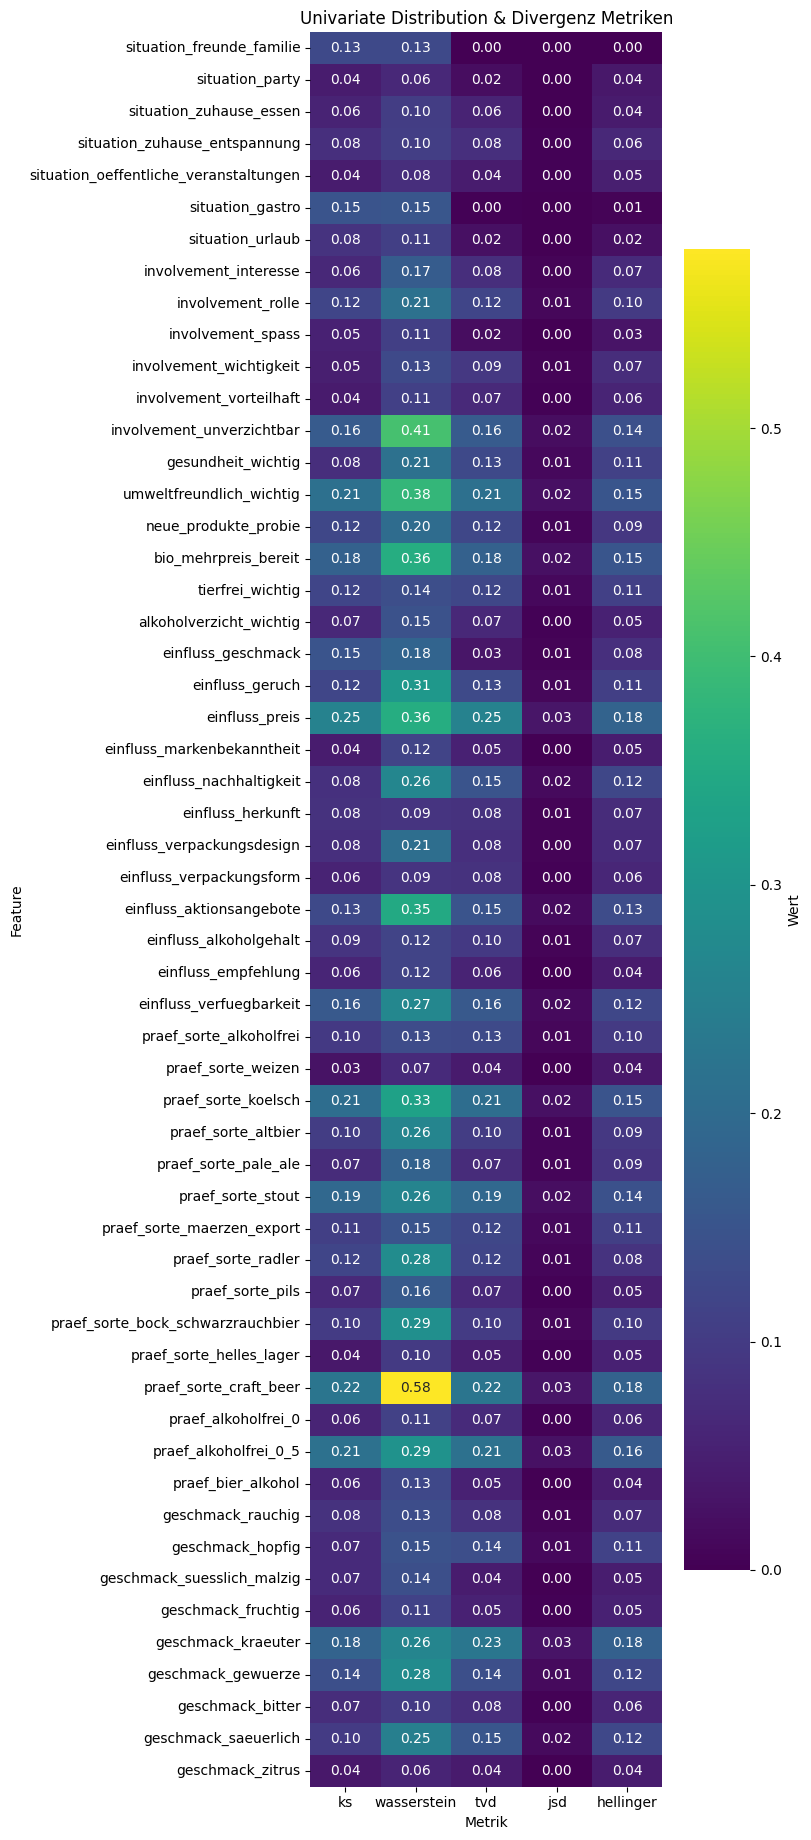

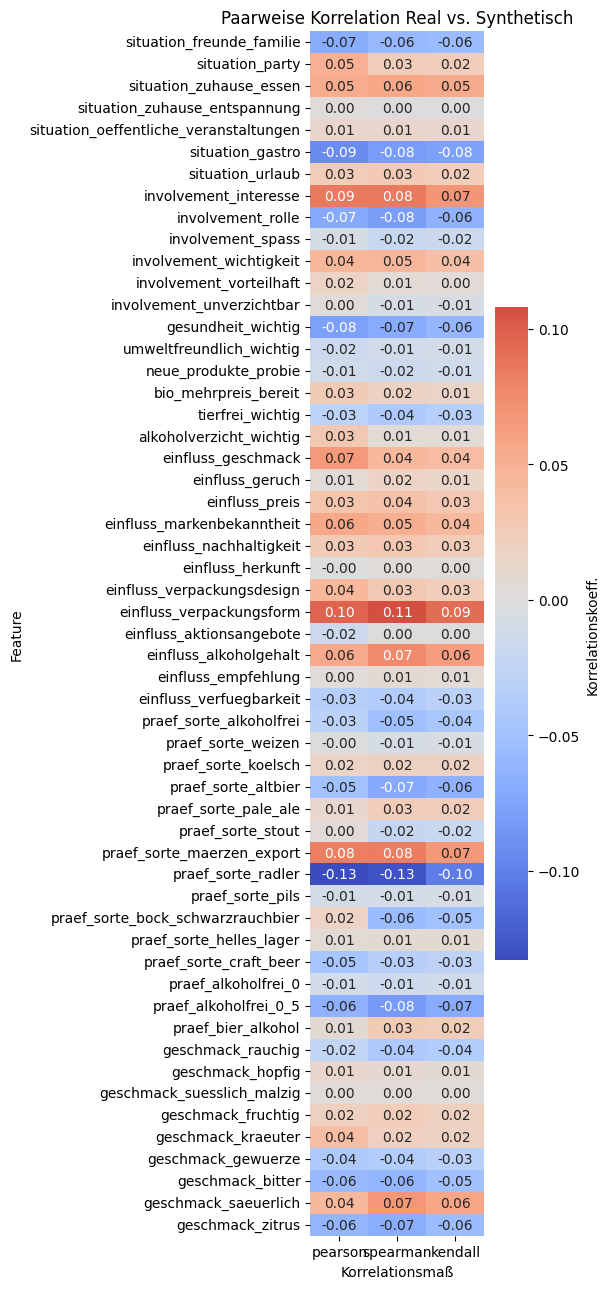

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, entropy, pearsonr, spearmanr, kendalltau

# --- Daten laden wie gehabt ---
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path  = "../../data/synthetic_result_data/536_synthetic_train_data.csv"
df_real = pd.read_csv(real_path)
df_syn  = pd.read_csv(syn_path)

# numerische Spalten
num_cols = df_real.select_dtypes(include="number") \
                  .columns.intersection(df_syn.select_dtypes(include="number").columns)

# --- 1. Univariate Distribution & Divergenz Metriken berechnen ---
def compute_univariate(df1, df2, cols):
    rows = []
    eps = 1e-8
    for col in cols:
        x = df1[col].dropna().values
        y = df2[col].dropna().values
        # KS
        ks, _ = ks_2samp(x, y)
        # Wasserstein
        wd = wasserstein_distance(x, y)
        # Histogramme für JSD, Hellinger, TVD
        edges = np.histogram_bin_edges(np.concatenate([x,y]), bins='auto')
        p, _ = np.histogram(x, edges, density=True)
        q, _ = np.histogram(y, edges, density=True)
        p += eps; q += eps
        p /= p.sum(); q /= q.sum()
        tvd = 0.5 * np.sum(np.abs(p - q))
        m = 0.5*(p+q)
        jsd = 0.5*(entropy(p, m) + entropy(q, m))
        hell = np.sqrt(0.5*np.sum((np.sqrt(p)-np.sqrt(q))**2))
        rows.append({
            'feature': col,
            'ks': ks,
            'wasserstein': wd,
            'tvd': tvd,
            'jsd': jsd,
            'hellinger': hell
        })
    return pd.DataFrame(rows).set_index('feature')

uni = compute_univariate(df_real, df_syn, num_cols)

# --- 2. Paarweise Korrelationsmaße (Real vs. Synth) ---
corr_rows = []
for col in num_cols:
    x = df_real[col].dropna()
    y = df_syn[col].dropna()
    r, _  = pearsonr(x, y)
    sr, _ = spearmanr(x, y)
    kt, _ = kendalltau(x, y)
    corr_rows.append({'feature': col, 'pearson': r, 'spearman': sr, 'kendall': kt})
corr_df = pd.DataFrame(corr_rows).set_index('feature')

# --- Plot 1: Univariate Metrics als Heatmap ---
plt.figure(figsize=(8, len(uni)*0.3+2))
sns.heatmap(uni, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label':'Wert'})
plt.title("Univariate Distribution & Divergenz Metriken")
plt.xlabel("Metrik")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- Plot 2: Paarweise Korrelationsmaße als Heatmap ---
plt.figure(figsize=(6, len(corr_df)*0.2+2))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={'label':'Korrelationskoeff.'})
plt.title("Paarweise Korrelation Real vs. Synthetisch")
plt.xlabel("Korrelationsmaß")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


| Metrik               | Wertebereich    | Interpretation (je niedriger, desto besser)                                            |
| -------------------- | --------------- | -------------------------------------------------------------------------------------- |
| **KS (D-Statistik)** | 0 … 1           | 0 = identisch, >0 größere maximale Verteilungslücke. Werte <0.1 sind meist sehr gut.   |
| **Wasserstein**      | 0 … ∞           | 0 = identisch, je größer desto mehr „Verschiebungs-Arbeit“. Typisch <0.5 gut.          |
| **TVD**              | 0 … 1           | 0 = identisch, bis 1=komplett unterschiedlich. <0.1 sehr gut, <0.2 noch ok.            |
| **JSD**              | 0 … ln(2) ≈0.69 | 0 = identisch, ln(2) maximal. <0.1 sehr realistisch, <0.2 noch akzeptabel.             |
| **Hellinger**        | 0 … 1           | 0 = identisch, bis 1=keine Überlappung. <0.2 ist gut, >0.3 zeigt deutliche Abweichung. |


| Metrik                             | Wertebereich | Interpretation                                                                                     |
| ---------------------------------- | ------------ | -------------------------------------------------------------------------------------------------- |
| **Korrelations-Frobenius-Distanz** | 0 … ∞        | 0 = identische Korrelationsmatrix. Je größer, desto stärker weichen multivariate Zusammenhänge ab. |
| **Kovarianz-Frobenius-Distanz**    | 0 … ∞        | 0 = identische Streuungsstruktur. Analog: kleiner = besser.                                        |


| Metrik         | Wertebereich | Interpretation                                                                                                 |
| -------------- | ------------ | -------------------------------------------------------------------------------------------------------------- |
| **Pearson r**  | −1 … +1      | +1 = perfekte lineare Übereinstimmung <br> 0 = kein linearer Zusammenhang <br> −1 = perfekte inverse Beziehung |
| **Spearman ρ** | −1 … +1      | +1 = perfekte monotone Rang-Korrelation                                                                        |
| **Kendall τ**  | −1 … +1      | +1 = perfektes Paar-Ranking, oft etwas kleiner als ρ                                                           |


Faustregeln
Sehr gut: Univariate-Metriken (KS, TVD, JSD, Hellinger) < 0.1, Wasserstein < 0.5
Gut: Univariate < 0.2, Divergenzen < 0.2
Akzeptabel: 0.2 … 0.3
Schlecht: > 0.3 deutliche Abweichungen
Multivariate Distanz: je näher an 0, desto besser
Korrelationskoeffizienten r/ρ/τ: > 0.8 sehr gut, 0.5 … 0.8 mittel, < 0.5 schwach
